## # EGFR pIC50 Data Curation

**Target:** EGFR kinase (ChEMBL ID: CHEMBL203)  
**Goal:** Build a clean, ML-ready dataset of EGFR binding affinities (pIC50) from ChEMBL.

## What this notebook does

1. **Fetch** IC50 activity data from ChEMBL (binding assays, Homo sapiens, exact measurements in nM)
2. **Clean** the activity values — drop missing/invalid IC50, convert to pIC50, filter to a physically plausible range [2, 12]
3. **Fetch SMILES** for all unique molecules and standardize them via RDKit
4. **Filter** inorganic compounds and fragment-like molecules
5. **Deduplicate** — collapse multiple assay measurements per molecule to a single median pIC50
6. **Save** the curated dataset to `data/processed/CHEMBL203_curated.parquet`

## pIC50 conversion

$$\text{pIC50} = -\log_{10}(\text{IC50}_\text{molar}) = 9 - \log_{10}(\text{IC50}_\text{nM})$$

Higher pIC50 = more potent. A pIC50 of 9 corresponds to IC50 = 1 nM (very potent); pIC50 of 5 corresponds to IC50 = 10 µM (weakly active).

In [1]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt


### 1. Fatching the data from chemble 

In [ ]:
TARGET_ID = "CHEMBL203"
target = new_client.target
activity = new_client.activity
molecule = new_client.molecule

# EFGR activities
print("Fetching efgr activities from chemble database")

results =activity.filter(
    target_chembl_id = TARGET_ID,
    assay_type="B",
    standard_type = 'IC50',
    standard_units = 'nM',
    standard_relation = '=',
    target_organism='Homo sapiens'

).only(
    "molecule_chembl_id",
    "standard_value",
    "standard_type",
    "standard_units",
    "standard_relation",
    "pchembl_value",
    "assay_chembl_id",
    "target_chembl_id",

)

Fetching efgr activities from chemble database


In [3]:
total_records = len(results)
print(f"Total records found: {total_records}")

Total records found: 18381


In [4]:
from tqdm import tqdm

In [5]:
# collect data with progress
data = []
for records in tqdm(results, total = total_records):
    data.append(records)

# convert to dataframe
df = pl.DataFrame(data)


100%|██████████| 18381/18381 [06:02<00:00, 50.77it/s]


In [ ]:
import os
os.makedirs("../data/raw", exist_ok=True)
df.to_parquet("../data/raw/CHEMBL203_raw.parquet")

In [11]:
df.head(20)

,assay_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_value,target_chembl_id,type,value
0,CHEMBL674637,CHEMBL68920,7.39,=,=,IC50,41.0,CHEMBL203,IC50,0.041
1,CHEMBL674637,CHEMBL69960,6.77,=,=,IC50,170.0,CHEMBL203,IC50,0.17
2,CHEMBL677833,CHEMBL137635,5.03,=,=,IC50,9300.0,CHEMBL203,IC50,9.3
3,CHEMBL674643,CHEMBL306988,None,=,=,IC50,500000.0,CHEMBL203,IC50,500.0
4,CHEMBL674643,CHEMBL66879,None,=,=,IC50,3000000.0,CHEMBL203,IC50,3000.0
5,CHEMBL674643,CHEMBL77085,4.02,=,=,IC50,96000.0,CHEMBL203,IC50,96.0
6,CHEMBL674637,CHEMBL443268,5.28,=,=,IC50,5310.0,CHEMBL203,IC50,5.31
7,CHEMBL674643,CHEMBL76979,None,=,=,IC50,264000.0,CHEMBL203,IC50,264.0
8,CHEMBL674643,CHEMBL76589,6.90,=,=,IC50,125.0,CHEMBL203,IC50,0.125
9,CHEMBL674643,CHEMBL76904,4.46,=,=,IC50,35000.0,CHEMBL203,IC50,35.0


In [97]:
df = pd.read_parquet('../data/raw/CHEMBL203_raw.parquet')

In [98]:
df = df[['molecule_chembl_id', 'standard_value']]

In [99]:
df.rename(columns={'standard_value': 'IC50'}, inplace=True)

In [100]:
df.head()

,molecule_chembl_id,IC50
0,CHEMBL68920,41.0
1,CHEMBL69960,170.0
2,CHEMBL137635,9300.0
3,CHEMBL306988,500000.0
4,CHEMBL66879,3000000.0


## 2. Data curation

In [101]:
# Convert to float, drop missing
df['IC50'] = pd.to_numeric(df['IC50'], errors='coerce')

In [102]:
df = df.dropna(subset=['IC50'])
df = df[df['IC50'] > 0]

In [103]:
df.shape

(18380, 2)

In [104]:
# convert IC50 to pIC50
df['pIC50'] = np.round(9 - np.log10(df['IC50']), 2) 

In [106]:
# Final pIC50 between 2 to 12
df = df[(df['pIC50'] >= 2) & (df['pIC50'] <= 12)]

In [108]:
df.shape


(18370, 3)

In [109]:
# Deduplicate molecules (mean pIC50 per molecule) take the median
df_dedup = df.groupby('molecule_chembl_id', as_index=False).agg('median')


Note: Several aggregation strategies are possible. You could use the mean of pIC50 or retain the minimum value. However, the median is more robust for machine learning applications.

In [110]:
df_dedup.shape

(10520, 3)

In [14]:
df_dedup.columns

Index(['molecule_chembl_id', 'IC50', 'pIC50'], dtype='object')

pIC50 range: 2.19 – 11.52
Median: 7.06
Count: 10520


Text(0.5, 1.0, 'EGFR IC50 Potency Distribution')

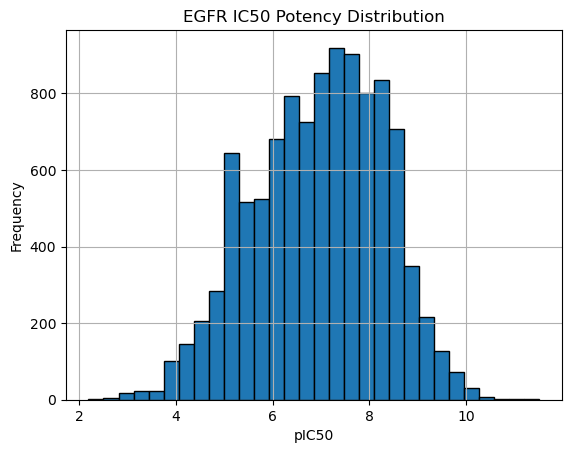

In [15]:
print(f"pIC50 range: {df_dedup['pIC50'].min():.2f} – {df_dedup['pIC50'].max():.2f}")
print(f"Median: {df_dedup['pIC50'].median():.2f}")
print(f"Count: {len(df_dedup)}")

# Histogram
df_dedup['pIC50'].hist(bins=30, edgecolor='black')
plt.xlabel('pIC50'); plt.ylabel('Frequency'); plt.title('EGFR IC50 Potency Distribution')

In [16]:
df_dedup['molecule_chembl_id'].nunique()

10520

## 3. Fetching the smiles of the molecules

In [17]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from chembl_webresource_client.new_client import new_client

def chunks(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

chembl_ids = df_dedup["molecule_chembl_id"].dropna().unique().tolist()

def fetch_batch(batch):
    # Create NEW client per thread - critical for thread safety
    molecule = new_client.molecule
    return list(molecule.filter(
        molecule_chembl_id__in=batch
    ).only(["molecule_chembl_id", "molecule_structures"]))

batch_size = 1000
batches = list(chunks(chembl_ids, batch_size))

all_molecules = []
with ThreadPoolExecutor(max_workers=6) as executor:
    futures = [executor.submit(fetch_batch, b) for b in batches]
    for f in tqdm(as_completed(futures), total=len(futures), desc="Fetching"):
        try:
            result = f.result()
            all_molecules.extend(result)
        except Exception as e:
            print(f"Batch failed: {e}")
            # Optional: retry logic here

Fetching:   0%|          | 0/11 [00:00<?, ?it/s]

In [18]:
mol_records = []

for mol in tqdm(
    all_molecules,
    desc="Extracting SMILES",
    unit="molecule"
):
    structures = mol.get("molecule_structures")

    mol_records.append({
        "molecule_chembl_id": mol["molecule_chembl_id"],
        "canonical_smiles": (
            structures.get("canonical_smiles")
            if structures else None
        )
    })

df_mol = pd.DataFrame(mol_records)

Extracting SMILES:   0%|          | 0/10520 [00:00<?, ?molecule/s]

In [19]:
df_mol.head()

,molecule_chembl_id,canonical_smiles
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...
1,CHEMBL11359,None
2,CHEMBL12131,Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)...
3,CHEMBL13485,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(C...
4,CHEMBL13629,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(B...


In [58]:
df_mol.shape

(10520, 2)

## 4. Data cleaning and standarize the smiles 

In [31]:
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.MolStandardize import rdMolStandardize
from concurrent.futures import ThreadPoolExecutor

In [28]:
# 1. Drop missing SMILES
df_mol = df_mol.dropna(subset=['canonical_smiles'])

# 2. Quick RDKit validation + canonicalization (catches any parse issues)
from rdkit import Chem

def quick_canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None

df_mol['smiles'] = df_mol['canonical_smiles'].apply(quick_canonicalize)
df_mol = df_mol.dropna(subset=['smiles'])

# 3. Remove structural duplicates
df_mol = df_mol.drop_duplicates('smiles')

In [ ]:
df_mol.shape

In [36]:
df_mol = df_mol[['molecule_chembl_id', 'smiles']]

In [48]:
from rdkit.Chem import PandasTools

# Add molecule column (creates 'ROMol' column)
PandasTools.AddMoleculeColumnToFrame(df_mol, smilesCol='smiles')


In [54]:
df_mol.head()

,molecule_chembl_id,smiles,ROMol
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,<rdkit.Chem.rdchem.Mol object at 0x127cc1fc0>
1,CHEMBL12131,Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)...,<rdkit.Chem.rdchem.Mol object at 0x127cc15b0>
2,CHEMBL13485,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(C...,<rdkit.Chem.rdchem.Mol object at 0x127cc1b60>
3,CHEMBL13629,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(B...,<rdkit.Chem.rdchem.Mol object at 0x127cc1bd0>
4,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,<rdkit.Chem.rdchem.Mol object at 0x127cc0660>


In [65]:
df_mol.columns


Index(['molecule_chembl_id', 'smiles', 'ROMol'], dtype='object')

In [75]:
from rdkit import Chem

# Create a column with atom counts
df_mol['atom_count'] = [
    Chem.MolFromSmiles(smiles).GetNumAtoms() if smiles else 0 
    for smiles in df_mol['smiles']
]

# Min and maximum atoms
min_atoms = df_mol['atom_count'].min()
max_atoms = df_mol['atom_count'].max()

print(f"Minimum atoms in SMILES: {min_atoms}")
print(f"Maximum atoms in SMILES: {max_atoms}")

# Optional: see which molecules have min/max atoms
min_atoms_mols = df_mol[df_mol['atom_count'] == min_atoms]
max_atoms_mols = df_mol[df_mol['atom_count'] == max_atoms]

print("\nMolecules with minimum atoms:")
print(min_atoms_mols[["smiles", "molecule_chembl_id"]])

print("\nMolecules with maximum atoms:")
print(max_atoms_mols[["smiles", "molecule_chembl_id"]])

Minimum atoms in SMILES: 3
Maximum atoms in SMILES: 103

Molecules with minimum atoms:
                 smiles molecule_chembl_id
547  [Cl-].[Cl-].[Zn+2]      CHEMBL1200679

Molecules with maximum atoms:
                                                 smiles molecule_chembl_id
6709  COc1cc(CC(=O)N2CC(=O)N[C@@H](Cc3ccccc3)C(=O)N(...      CHEMBL5082149


In [84]:
# 1. Define a helper function to check for the absence of Carbon (Atomic Number 6)
def has_no_carbon(mol):
    if mol is None:
        return False  # Handles empty or invalid molecule objects
    # Returns True if NONE of the atoms have an atomic number of 6 (Carbon)
    return not any(atom.GetAtomicNum() == 6 for atom in mol.GetAtoms())

# 2. Apply the function to filter your DataFrame
no_carbon_df = df_mol[df_mol['ROMol'].apply(has_no_carbon)]

# 3. Print how many molecules were found
print(f"Total molecules without any carbon atoms: {len(no_carbon_df)}")

# 4. View the resulting molecules
print(no_carbon_df[['molecule_chembl_id', 'smiles']])

Total molecules without any carbon atoms: 1
    molecule_chembl_id              smiles
547      CHEMBL1200679  [Cl-].[Cl-].[Zn+2]


In [80]:
no_carbon_df

,molecule_chembl_id,smiles,ROMol,atom_count
547,CHEMBL1200679,[Cl-].[Cl-].[Zn+2],<rdkit.Chem.rdchem.Mol object at 0x127cb23b0>,3


In [86]:
# 1. Keep only the molecules that HAVE carbon (using ~ to invert the filter)
df_cleaned = df_mol[~df_mol['ROMol'].apply(has_no_carbon)]

# 2. Verify how many molecules were removed
removed_count = len(df_mol) - len(df_cleaned)
print(f"Removed {removed_count} molecules without carbon.")
print(f"New dataset size: {len(df_cleaned)} molecules.")

Removed 1 molecules without carbon.
New dataset size: 10502 molecules.


## Filter compound with less then 5 atoms

In [ ]:
# Filter for molecules with fewer than 5 heavy atoms
small_mols_df = df_cleaned[df_cleaned['ROMol'].apply(lambda mol: mol.GetNumAtoms() < 5 if mol else False)]
print(f"Molecules with fewer than 5 heavy atoms (removed): {len(small_mols_df)}")
print(small_mols_df[['molecule_chembl_id', 'smiles']])

# Remove them
df_cleaned = df_cleaned[df_cleaned['ROMol'].apply(lambda mol: mol.GetNumAtoms() >= 5 if mol else False)]
print(f"\nRemaining after small-molecule filter: {len(df_cleaned)}")

In [89]:
# Merging back the smiles datafram to pIC50 
df_curated = pd.merge(
    df_cleaned[['molecule_chembl_id', 'smiles']],
    df_dedup,
    on='molecule_chembl_id',

)

In [90]:
print(f"Dataset with {df_curated.shape[0]} records.")

Dataset with 10502 records.


In [92]:
df_curated.head()

,molecule_chembl_id,smiles,IC50,pIC50
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,53000.0,4.51
1,CHEMBL12131,Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)...,564.0,6.25
2,CHEMBL13485,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(C...,3000.0,5.52
3,CHEMBL13629,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(B...,10000.0,5.00
4,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,69421.0,4.16


## 5. Save the cleaned and curated dataset.

In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)
df_curated.to_parquet('../data/processed/CHEMBL203_curated.parquet', index=False)
print(f"Saved {len(df_curated)} curated records → data/processed/CHEMBL203_curated.parquet")

## 6. Curation Summary

In [113]:
steps = [
    ("ChEMBL fetch (assay_type=B, IC50, nM, =, Homo sapiens)", 18381),
    ("Drop NaN IC50 + IC50 <= 0",                               18380),
    ("pIC50 range filter [2, 12]",                              18370),   
    ("Deduplicate by molecule_chembl_id (median)",              10520),
    ("Fetch SMILES + RDKit validation + structural dedup",      10503),
    ("Remove non-carbon molecules",                             10502),
    ("Final curated dataset",                                   len(df_curated)),
]

print(f"{'Step':<52} {'Count':>7}  {'Removed':>8}")
print("-" * 72)
prev = None
for name, count in steps:
    removed = f"{prev - count:>8}" if (prev is not None and count is not None) else "       —"
    count_str = f"{count:>7}" if count is not None else "      ?"
    print(f"{name:<52} {count_str}  {removed}")
    if count is not None:
        prev = count

Step                                                   Count   Removed
------------------------------------------------------------------------
ChEMBL fetch (assay_type=B, IC50, nM, =, Homo sapiens)   18381         —
Drop NaN IC50 + IC50 <= 0                              18380         1
pIC50 range filter [2, 12]                             18370        10
Deduplicate by molecule_chembl_id (median)             10520      7850
Fetch SMILES + RDKit validation + structural dedup     10503        17
Remove non-carbon molecules                            10502         1
Final curated dataset                                  10502         0
